# 05｜CLIP Feature Adapter（對照實驗）

在 03 的凍結 CLIP 基準之上，於**特徵層之後**加入一個輕量 Adapter，測試「只在最終特徵上動手腳」能否帶來增益。

設定：

- CLIP ViT-B/16 主幹維持完全凍結。
- 載入 03 已訓練完成的分類頭作為起點。
- 新增 512→128→512 的殘差瓶頸 Adapter，可訓練參數 133,762 個。
- Adapter 最後一層零初始化，因此訓練開始前模型輸出與 03 完全相同。這讓任何差異都能明確歸因於訓練過程，而不是初始化的隨機擾動。
- 最佳權重仍只依 FF++ 驗證集 video-level AUC 選取。

這是對照實驗，不是 Forensics Adapter 的重現。完整方法需要 blending mask、x-ray 監督、patch label 與跨層 token 互動，那些在 06 與 07 處理。

本實驗的結果為**負向**，詳見末節。

## 實驗定位

這一步要回答的問題是：CLIP 最終輸出的 512 維特徵裡，還剩下多少可供偵測偽造的資訊？

如果在這層之後加參數就能提升表現，代表資訊還在，只是基準的線性分類頭表達力不足。如果加了也沒用，代表資訊在傳到最後一層的過程中已經流失，必須從更淺的層取。

In [1]:
from pathlib import Path
import json
import math
import os
import platform
import random
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

try:
    import open_clip
except ImportError as exc:
    raise ImportError(
        "尚未安裝 open_clip_torch。請先執行 "
        "%pip install -U open_clip_torch scikit-learn seaborn，"
        "再重新啟動 Kernel。"
    ) from exc


def setup_chinese_font():
    system = platform.system()
    if system == "Windows":
        candidates = ["Microsoft JhengHei", "Microsoft YaHei", "SimHei"]
    elif system == "Darwin":
        candidates = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
    else:
        candidates = ["Noto Sans CJK TC", "Noto Sans CJK SC", "WenQuanYi Zen Hei"]

    plt.rcParams["font.sans-serif"] = candidates + ["DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    return candidates


FONT_CANDIDATES = setup_chinese_font()
print("Python：", sys.version.split()[0])
print("PyTorch：", torch.__version__)
print("OpenCLIP：", getattr(open_clip, "__version__", "未知"))
print("CUDA 可用：", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU：", torch.cuda.get_device_name(0))


Python： 3.10.19
PyTorch： 2.5.1+cu121
OpenCLIP： 3.3.0
CUDA 可用： True
GPU： NVIDIA GeForce RTX 4070


## 1. 路徑與訓練參數

In [2]:
# 只需要修改這一格
FACE_ROOT = Path("./FFPP_Deepfakes_16frames_faces")
OUTPUT_ROOT = Path("./FFPP_CLIP_Adapter_Results")
BASELINE_BEST_MODEL_PATH = Path(
    "./FFPP_CLIP_Baseline_Results/"
    "clip_vit_b16_ffpp_deepfakes/best_model.pth"
)

MODEL_NAME = "ViT-B-16-quickgelu"
PRETRAINED = "openai"
IMAGE_SIZE = 224

# Feature Adapter 設定
ADAPTER_HIDDEN_DIM = 128
ADAPTER_SCALE = 0.2
ADAPTER_DROPOUT = 0.1
INITIALIZE_FROM_BASELINE = True

SEED = 42
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 15
ADAPTER_LEARNING_RATE = 3e-4
CLASSIFIER_LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 5
GRAD_CLIP_NORM = 1.0

# 第一次請維持 True，只取少量影片檢查完整流程
SMOKE_TEST = False
SMOKE_VIDEOS_PER_GROUP = 8
SMOKE_EPOCHS = 2

# 安全開關
RUN_TRAINING = True
RUN_TEST = False

# 若訓練中斷，True 會讀取 last_checkpoint.pth 接續
RESUME_TRAINING = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
PIN_MEMORY = DEVICE.type == "cuda"

FACE_MANIFEST = FACE_ROOT / "metadata" / "face_manifest.csv"
RUN_NAME = (
    "clip_vit_b16_adapter_smoke"
    if SMOKE_TEST
    else "clip_vit_b16_adapter_ffpp_deepfakes"
)
RUN_DIR = OUTPUT_ROOT / RUN_NAME
BEST_MODEL_PATH = RUN_DIR / "best_model.pth"
LAST_CHECKPOINT_PATH = RUN_DIR / "last_checkpoint.pth"
HISTORY_PATH = RUN_DIR / "training_history.csv"
CONFIG_PATH = RUN_DIR / "config.json"
TEST_FRAME_PATH = RUN_DIR / "test_frame_predictions.csv"
TEST_VIDEO_PATH = RUN_DIR / "test_video_predictions.csv"
TEST_METRICS_PATH = RUN_DIR / "test_metrics.json"

print("人臉資料：", FACE_ROOT.resolve())
print("Baseline 權重：", BASELINE_BEST_MODEL_PATH.resolve())
print("輸出資料夾：", RUN_DIR.resolve())
print("裝置：", DEVICE)
print("Mixed Precision：", USE_AMP)
print("Smoke Test：", SMOKE_TEST)
print("訓練安全開關：", RUN_TRAINING)
print("測試安全開關：", RUN_TEST)


人臉資料： D:\資料\專題\PY\deepfake\新版專題研究\FFPP_Deepfakes_16frames_faces
Baseline 權重： D:\資料\專題\PY\deepfake\新版專題研究\FFPP_CLIP_Baseline_Results\clip_vit_b16_ffpp_deepfakes\best_model.pth
輸出資料夾： D:\資料\專題\PY\deepfake\新版專題研究\FFPP_CLIP_Adapter_Results\clip_vit_b16_adapter_ffpp_deepfakes
裝置： cuda
Mixed Precision： True
Smoke Test： False
訓練安全開關： True
測試安全開關： False


### 學習率設定

Adapter 使用 3e-4，分類頭使用 1e-4。分類頭已在 03 訓練收斂，此處只需微調；新增的 Adapter 從零開始，需要較大的學習率。

## 2. 固定隨機種子

In [3]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)


seed_everything(SEED)
print("Random Seed：", SEED)


Random Seed： 42


## 3. 讀取清單並檢查資料洩漏

檢查項目與 03 完全相同：類別索引固定、身分不跨 split。兩個實驗使用同一份資料，任何差異都不來自資料。

In [4]:
if not FACE_MANIFEST.is_file():
    raise FileNotFoundError(f"找不到 face_manifest.csv：{FACE_MANIFEST.resolve()}")

manifest_df = pd.read_csv(FACE_MANIFEST)
required_columns = {
    "face_path",
    "video_stem",
    "split",
    "label",
    "class_name",
    "status",
}
missing_columns = sorted(required_columns - set(manifest_df.columns))
if missing_columns:
    raise ValueError(f"face_manifest.csv 缺少欄位：{missing_columns}")

manifest_df = manifest_df[manifest_df["status"].eq("ok")].copy()
manifest_df["split"] = manifest_df["split"].astype(str).str.lower()
manifest_df["class_name"] = manifest_df["class_name"].astype(str).str.lower()
manifest_df["label"] = manifest_df["label"].astype(int)
manifest_df["video_stem"] = manifest_df["video_stem"].astype(str)
manifest_df["face_path"] = manifest_df["face_path"].astype(str)

expected_labels = {"real": 0, "fake": 1}
observed_mapping = (
    manifest_df[["class_name", "label"]]
    .drop_duplicates()
    .set_index("class_name")["label"]
    .to_dict()
)
if observed_mapping != expected_labels:
    raise ValueError(
        f"類別索引錯誤：目前為 {observed_mapping}，必須固定為 {expected_labels}"
    )

invalid_splits = manifest_df[~manifest_df["split"].isin(["train", "val", "test"])]
duplicate_paths = manifest_df[manifest_df["face_path"].duplicated(keep=False)]
if len(invalid_splits) or len(duplicate_paths):
    raise ValueError(
        f"資料清單異常：無效 split={len(invalid_splits)}，"
        f"重複 face_path={len(duplicate_paths)}"
    )


def resolve_face_path(row):
    original = Path(row["face_path"])
    if original.is_file():
        return original

    candidate = (
        FACE_ROOT
        / row["split"]
        / row["class_name"]
        / row["video_stem"]
        / original.name
    )
    return candidate


manifest_df["resolved_face_path"] = manifest_df.apply(
    lambda row: str(resolve_face_path(row)), axis=1
)
manifest_df["file_exists"] = manifest_df["resolved_face_path"].map(
    lambda value: Path(value).is_file()
)
missing_files = manifest_df[~manifest_df["file_exists"]]
if len(missing_files):
    display(missing_files[["face_path", "resolved_face_path"]].head(20))
    raise FileNotFoundError(f"共有 {len(missing_files):,} 張裁切圖片不存在。")

# Fake 檔名通常為 000_003，兩個來源 ID 都必須留在相同 split
def source_ids(row):
    parts = row["video_stem"].split("_")
    return parts if row["class_name"] == "fake" else [row["video_stem"]]


identity_split_records = []
for row in manifest_df[["video_stem", "class_name", "split"]].drop_duplicates().to_dict("records"):
    for identity_id in source_ids(row):
        identity_split_records.append(
            {"identity_id": identity_id, "split": row["split"]}
        )

identity_split_df = pd.DataFrame(identity_split_records).drop_duplicates()
cross_split_ids = (
    identity_split_df.groupby("identity_id")["split"].nunique().loc[lambda s: s > 1]
)
if len(cross_split_ids):
    raise ValueError(
        f"發現 {len(cross_split_ids)} 個來源 ID 跨越不同 split，存在資料洩漏。"
    )

manifest_df["video_key"] = (
    manifest_df["class_name"] + "::" + manifest_df["video_stem"]
)

print(f"成功裁切圖片：{len(manifest_df):,}")
print(f"影片數：{manifest_df['video_key'].nunique():,}")
print("跨 split 的來源 ID：0")
display(pd.crosstab(manifest_df["split"], manifest_df["class_name"], margins=True))
display(
    manifest_df.groupby(["split", "class_name"])["video_key"]
    .nunique()
    .unstack(fill_value=0)
)


成功裁切圖片：31,996
影片數：2,000
跨 split 的來源 ID：0


class_name,fake,real,All
split,,,
test,2240,2240,4480
train,11520,11518,23038
val,2239,2239,4478
All,15999,15997,31996


class_name,fake,real
split,,
test,140,140
train,720,720
val,140,140


## 4. 建立訓練資料

In [5]:
def select_smoke_videos(df, videos_per_group, seed):
    selected_keys = []
    for (split_name, class_name), group in df.groupby(["split", "class_name"]):
        keys = sorted(group["video_key"].unique())
        rng = np.random.default_rng(seed)
        count = min(videos_per_group, len(keys))
        chosen = rng.choice(keys, size=count, replace=False).tolist()
        selected_keys.extend(chosen)
    return df[df["video_key"].isin(selected_keys)].copy()


if SMOKE_TEST:
    working_df = select_smoke_videos(
        manifest_df,
        videos_per_group=SMOKE_VIDEOS_PER_GROUP,
        seed=SEED,
    )
    current_epochs = SMOKE_EPOCHS
else:
    working_df = manifest_df.copy()
    current_epochs = EPOCHS

split_dfs = {
    split_name: working_df[working_df["split"].eq(split_name)]
    .sort_values(["class_name", "video_stem", "resolved_face_path"])
    .reset_index(drop=True)
    for split_name in ["train", "val", "test"]
}

for split_name, df in split_dfs.items():
    if df.empty:
        raise ValueError(f"{split_name} 沒有可用資料。")

print("本次執行資料：")
display(pd.crosstab(working_df["split"], working_df["class_name"], margins=True))
print("本次 Epoch 數：", current_epochs)


本次執行資料：


class_name,fake,real,All
split,,,
test,2240,2240,4480
train,11520,11518,23038
val,2239,2239,4478
All,15999,15997,31996


本次 Epoch 數： 15


## 5. Dataset 與前處理

與 03 使用相同的增強設定與相同的隨機種子。

In [6]:
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD = (0.26862954, 0.26130258, 0.27577711)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.85, 1.0),
        ratio=(0.95, 1.05),
        interpolation=transforms.InterpolationMode.BICUBIC,
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=transforms.InterpolationMode.BICUBIC,
    ),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
])


class FaceManifestDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        path = Path(row["resolved_face_path"])
        with Image.open(path) as image:
            image = image.convert("RGB")
            image = self.transform(image)

        return {
            "image": image,
            "label": torch.tensor(int(row["label"]), dtype=torch.long),
            "path": str(path),
            "video_key": str(row["video_key"]),
            "video_stem": str(row["video_stem"]),
            "class_name": str(row["class_name"]),
        }


datasets = {
    "train": FaceManifestDataset(split_dfs["train"], train_transform),
    "val": FaceManifestDataset(split_dfs["val"], eval_transform),
    "test": FaceManifestDataset(split_dfs["test"], eval_transform),
}

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

dataloaders = {
    "train": DataLoader(
        datasets["train"],
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
        generator=loader_generator,
    ),
    "val": DataLoader(
        datasets["val"],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
    ),
    "test": DataLoader(
        datasets["test"],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
    ),
}

for split_name in ["train", "val", "test"]:
    print(
        f"{split_name}: {len(datasets[split_name]):,} 張，"
        f"{len(dataloaders[split_name]):,} batches"
    )


train: 23,038 張，720 batches
val: 4,478 張，140 batches
test: 4,480 張，140 batches


## 6. 建立凍結 CLIP 與 Feature Adapter

Adapter 為殘差結構：輸出等於輸入加上瓶頸分支的結果乘以 `ADAPTER_SCALE`。最後一層零初始化，配合殘差連接，訓練前的等效輸出與 03 相同。

In [7]:
class ResidualFeatureAdapter(nn.Module):
    def __init__(self, feature_dim, hidden_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, feature_dim),
        )

        # 讓 Adapter 一開始輸出 0，初始模型等同 Frozen CLIP Baseline
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, features):
        return self.net(features)


class CLIPFeatureAdapterClassifier(nn.Module):
    def __init__(
        self,
        model_name,
        pretrained,
        adapter_hidden_dim,
        adapter_scale,
        adapter_dropout,
        num_classes=2,
    ):
        super().__init__()
        self.backbone = open_clip.create_model(
            model_name,
            pretrained=pretrained,
        )
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False

        feature_dim = int(self.backbone.visual.output_dim)
        self.adapter_scale = float(adapter_scale)
        self.adapter = ResidualFeatureAdapter(
            feature_dim,
            adapter_hidden_dim,
            adapter_dropout,
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(feature_dim),
            nn.Linear(feature_dim, num_classes),
        )

    def train(self, mode=True):
        super().train(mode)
        self.backbone.eval()
        self.adapter.train(mode)
        self.classifier.train(mode)
        return self

    def forward(self, images):
        with torch.no_grad():
            features = self.backbone.encode_image(images)
            features = features.float()
            features = features / features.norm(
                dim=-1,
                keepdim=True,
            ).clamp_min(1e-6)

        adapted_features = (
            features + self.adapter_scale * self.adapter(features)
        )
        adapted_features = adapted_features / adapted_features.norm(
            dim=-1,
            keepdim=True,
        ).clamp_min(1e-6)
        return self.classifier(adapted_features)


model = CLIPFeatureAdapterClassifier(
    MODEL_NAME,
    PRETRAINED,
    ADAPTER_HIDDEN_DIM,
    ADAPTER_SCALE,
    ADAPTER_DROPOUT,
).to(DEVICE)

INITIAL_BEST_VAL_AUC = -math.inf
if INITIALIZE_FROM_BASELINE:
    if not BASELINE_BEST_MODEL_PATH.is_file():
        raise FileNotFoundError(
            f"找不到 Baseline best_model.pth："
            f"{BASELINE_BEST_MODEL_PATH.resolve()}"
        )

    baseline_checkpoint = torch.load(
        BASELINE_BEST_MODEL_PATH,
        map_location="cpu",
        weights_only=False,
    )
    baseline_config = baseline_checkpoint.get("config", {})
    for key, expected_value in {
        "model_name": MODEL_NAME,
        "pretrained": PRETRAINED,
        "image_size": IMAGE_SIZE,
    }.items():
        saved_value = baseline_config.get(key)
        if saved_value is not None and saved_value != expected_value:
            raise ValueError(
                f"Baseline checkpoint 的 {key}={saved_value}，"
                f"但目前設定為 {expected_value}。"
            )

    baseline_state = baseline_checkpoint["model_state_dict"]
    classifier_state = {
        key.removeprefix("classifier."): value
        for key, value in baseline_state.items()
        if key.startswith("classifier.")
    }
    if not classifier_state:
        raise KeyError("Baseline checkpoint 找不到 classifier 權重。")

    model.classifier.load_state_dict(classifier_state, strict=True)
    INITIAL_BEST_VAL_AUC = float(
        baseline_checkpoint.get("best_val_auc", -math.inf)
    )
    del baseline_checkpoint, baseline_state, classifier_state
    print("已載入 Baseline 分類頭。")
    print("Baseline 最佳驗證 Video AUC：", INITIAL_BEST_VAL_AUC)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)
adapter_parameters = sum(
    parameter.numel() for parameter in model.adapter.parameters()
)
classifier_parameters = sum(
    parameter.numel() for parameter in model.classifier.parameters()
)
total_parameters = sum(parameter.numel() for parameter in model.parameters())

print(f"總參數：{total_parameters:,}")
print(f"Adapter 參數：{adapter_parameters:,}")
print(f"分類頭參數：{classifier_parameters:,}")
print(f"可訓練參數：{trainable_parameters:,}")
print(f"可訓練比例：{trainable_parameters / total_parameters:.4%}")

sample_batch = next(iter(dataloaders["train"]))
with torch.no_grad():
    sample_logits = model(sample_batch["image"][:2].to(DEVICE))
print("輸入形狀：", tuple(sample_batch["image"][:2].shape))
print("輸出形狀：", tuple(sample_logits.shape))


已載入 Baseline 分類頭。
Baseline 最佳驗證 Video AUC： 0.9825510204081633
總參數：149,754,499
Adapter 參數：131,712
分類頭參數：2,050
可訓練參數：133,762
可訓練比例：0.0893%
輸入形狀： (2, 3, 224, 224)
輸出形狀： (2, 2)


## 7. 指標與訓練函式

In [8]:
def safe_auc(labels, probabilities):
    labels = np.asarray(labels)
    probabilities = np.asarray(probabilities)
    if np.unique(labels).size < 2:
        return float("nan")
    return float(roc_auc_score(labels, probabilities))


def binary_metrics(labels, probabilities, threshold=0.5):
    labels = np.asarray(labels, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = (probabilities >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0,
    )
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auc": safe_auc(labels, probabilities),
    }


def aggregate_video_predictions(frame_df):
    return (
        frame_df.groupby(["video_key", "video_stem", "class_name"], as_index=False)
        .agg(
            label=("label", "first"),
            fake_probability=("fake_probability", "mean"),
            frame_count=("fake_probability", "size"),
        )
    )


def run_epoch(model, dataloader, criterion, optimizer=None, scaler=None):
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    records = []
    progress = tqdm(
        dataloader,
        desc="Train" if is_training else "Evaluate",
        leave=False,
    )

    for batch in progress:
        images = batch["image"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):
                logits = model(images)
                loss = criterion(logits, labels)

            if is_training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad],
                    GRAD_CLIP_NORM,
                )
                scaler.step(optimizer)
                scaler.update()

        probabilities = torch.softmax(logits.detach(), dim=1)[:, 1]
        total_loss += loss.item() * images.size(0)

        for index in range(images.size(0)):
            records.append({
                "path": batch["path"][index],
                "video_key": batch["video_key"][index],
                "video_stem": batch["video_stem"][index],
                "class_name": batch["class_name"][index],
                "label": int(labels[index].detach().cpu()),
                "fake_probability": float(probabilities[index].cpu()),
            })

        progress.set_postfix(loss=f"{loss.item():.4f}")

    frame_df = pd.DataFrame(records)
    video_df = aggregate_video_predictions(frame_df)
    frame_metrics = binary_metrics(
        frame_df["label"],
        frame_df["fake_probability"],
    )
    video_metrics = binary_metrics(
        video_df["label"],
        video_df["fake_probability"],
    )
    average_loss = total_loss / len(dataloader.dataset)
    return average_loss, frame_metrics, video_metrics, frame_df, video_df


## 8. Optimizer、Scheduler 與 Checkpoint

Adapter 與分類頭分為兩個參數群組，各自使用不同學習率。

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    [
        {
            "params": model.adapter.parameters(),
            "lr": ADAPTER_LEARNING_RATE,
            "name": "adapter",
        },
        {
            "params": model.classifier.parameters(),
            "lr": CLASSIFIER_LEARNING_RATE,
            "name": "classifier",
        },
    ],
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(1, current_epochs),
)
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)


def serializable_config():
    return {
        "face_manifest": str(FACE_MANIFEST.resolve()),
        "baseline_best_model": str(BASELINE_BEST_MODEL_PATH.resolve()),
        "model_name": MODEL_NAME,
        "pretrained": PRETRAINED,
        "image_size": IMAGE_SIZE,
        "adapter_type": "residual_feature_bottleneck",
        "adapter_hidden_dim": ADAPTER_HIDDEN_DIM,
        "adapter_scale": ADAPTER_SCALE,
        "adapter_dropout": ADAPTER_DROPOUT,
        "initialize_from_baseline": INITIALIZE_FROM_BASELINE,
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "epochs": current_epochs,
        "adapter_learning_rate": ADAPTER_LEARNING_RATE,
        "classifier_learning_rate": CLASSIFIER_LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "grad_clip_norm": GRAD_CLIP_NORM,
        "smoke_test": SMOKE_TEST,
        "label_mapping": {"real": 0, "fake": 1},
        "selection_metric": "validation video-level AUC",
        "checkpoint_scope": "adapter_and_classifier_only",
        "train_images": len(datasets["train"]),
        "val_images": len(datasets["val"]),
        "test_images": len(datasets["test"]),
    }


def trainable_state_dict():
    prefixes = ("adapter.", "classifier.")
    return {
        name: tensor.detach().cpu()
        for name, tensor in model.state_dict().items()
        if name.startswith(prefixes)
    }


def load_trainable_state(state_dict):
    result = model.load_state_dict(state_dict, strict=False)
    invalid_missing = [
        name
        for name in result.missing_keys
        if not name.startswith("backbone.")
    ]
    if invalid_missing or result.unexpected_keys:
        raise RuntimeError(
            f"Adapter checkpoint 不相容：missing={invalid_missing}，"
            f"unexpected={result.unexpected_keys}"
        )


def save_checkpoint(path, epoch, best_val_auc, patience_count, history):
    payload = {
        "epoch": epoch,
        "model_state_dict": trainable_state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_val_auc": best_val_auc,
        "patience_count": patience_count,
        "history": history,
        "config": serializable_config(),
    }
    torch.save(payload, path)


RUN_DIR.mkdir(parents=True, exist_ok=True)
with CONFIG_PATH.open("w", encoding="utf-8") as file:
    json.dump(serializable_config(), file, ensure_ascii=False, indent=2)

print("設定已寫入：", CONFIG_PATH)
print("Checkpoint 只保存 Adapter 與分類頭，不重複保存凍結的 CLIP 主幹。")


設定已寫入： FFPP_CLIP_Adapter_Results\clip_vit_b16_adapter_ffpp_deepfakes\config.json
Checkpoint 只保存 Adapter 與分類頭，不重複保存凍結的 CLIP 主幹。


## 9. 訓練

In [10]:
start_epoch = 0
best_val_auc = INITIAL_BEST_VAL_AUC
patience_count = 0
history = []

if RESUME_TRAINING and LAST_CHECKPOINT_PATH.is_file():
    checkpoint = torch.load(
        LAST_CHECKPOINT_PATH,
        map_location=DEVICE,
        weights_only=False,
    )
    saved_config = checkpoint.get("config", {})
    current_config = serializable_config()
    keys_to_match = [
        "model_name",
        "pretrained",
        "seed",
        "batch_size",
        "adapter_hidden_dim",
        "adapter_scale",
        "adapter_dropout",
        "adapter_learning_rate",
        "classifier_learning_rate",
        "weight_decay",
        "smoke_test",
    ]
    mismatch = {
        key: (saved_config.get(key), current_config.get(key))
        for key in keys_to_match
        if saved_config.get(key) != current_config.get(key)
    }
    if mismatch:
        raise ValueError(
            f"現有 checkpoint 與本次設定不一致：{mismatch}。"
            "請改用新的 RUN_NAME，或確認後移走舊 checkpoint。"
        )

    load_trainable_state(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    scaler.load_state_dict(checkpoint["scaler_state_dict"])
    start_epoch = int(checkpoint["epoch"]) + 1
    best_val_auc = float(checkpoint["best_val_auc"])
    patience_count = int(checkpoint["patience_count"])
    history = list(checkpoint.get("history", []))
    print(f"已從 Epoch {start_epoch} 接續訓練。")
elif INITIALIZE_FROM_BASELINE and math.isfinite(best_val_auc):
    # Adapter 初始為零，因此這個 checkpoint 等同原 Baseline。
    # 若後續 Epoch 未改善驗證 AUC，仍保留公平的 Baseline 起點。
    save_checkpoint(
        BEST_MODEL_PATH,
        epoch=-1,
        best_val_auc=best_val_auc,
        patience_count=0,
        history=[],
    )
    print("已將 Baseline 等效起點保存為初始最佳模型。")

if not RUN_TRAINING:
    print("目前 RUN_TRAINING=False，尚未開始訓練。")
    print("確認前面所有檢查正常後，改成 True 再執行本格。")
elif start_epoch >= current_epochs:
    print("checkpoint 已完成設定的 Epoch 數，不需重複訓練。")
else:
    training_start = time.time()

    for epoch in range(start_epoch, current_epochs):
        print(f"\nEpoch {epoch + 1}/{current_epochs}")

        train_loss, train_frame, train_video, _, _ = run_epoch(
            model,
            dataloaders["train"],
            criterion,
            optimizer=optimizer,
            scaler=scaler,
        )
        with torch.no_grad():
            val_loss, val_frame, val_video, _, _ = run_epoch(
                model,
                dataloaders["val"],
                criterion,
            )

        adapter_lr = optimizer.param_groups[0]["lr"]
        classifier_lr = optimizer.param_groups[1]["lr"]
        row = {
            "epoch": epoch + 1,
            "learning_rate": adapter_lr,
            "adapter_learning_rate": adapter_lr,
            "classifier_learning_rate": classifier_lr,
            "train_loss": train_loss,
            "train_frame_accuracy": train_frame["accuracy"],
            "train_frame_f1": train_frame["f1"],
            "train_frame_auc": train_frame["auc"],
            "train_video_auc": train_video["auc"],
            "val_loss": val_loss,
            "val_frame_accuracy": val_frame["accuracy"],
            "val_frame_precision": val_frame["precision"],
            "val_frame_recall": val_frame["recall"],
            "val_frame_f1": val_frame["f1"],
            "val_frame_auc": val_frame["auc"],
            "val_video_accuracy": val_video["accuracy"],
            "val_video_precision": val_video["precision"],
            "val_video_recall": val_video["recall"],
            "val_video_f1": val_video["f1"],
            "val_video_auc": val_video["auc"],
        }
        history.append(row)
        pd.DataFrame(history).to_csv(
            HISTORY_PATH,
            index=False,
            encoding="utf-8-sig",
        )

        scheduler.step()
        improved = (
            not math.isnan(val_video["auc"])
            and val_video["auc"] > best_val_auc + 1e-6
        )
        if improved:
            best_val_auc = val_video["auc"]
            patience_count = 0
            save_checkpoint(
                BEST_MODEL_PATH,
                epoch,
                best_val_auc,
                patience_count,
                history,
            )
            marker = "，已更新最佳模型"
        else:
            patience_count += 1
            marker = ""

        save_checkpoint(
            LAST_CHECKPOINT_PATH,
            epoch,
            best_val_auc,
            patience_count,
            history,
        )

        print(
            f"Train Loss={train_loss:.4f} | "
            f"Val Loss={val_loss:.4f} | "
            f"Val Frame AUC={val_frame['auc']:.4f} | "
            f"Val Video AUC={val_video['auc']:.4f}"
            f"{marker}"
        )

        if patience_count >= EARLY_STOPPING_PATIENCE:
            print(
                f"驗證集 Video AUC 連續 {patience_count} 個 Epoch 未改善，"
                "提前停止訓練。"
            )
            break

    elapsed = (time.time() - training_start) / 60
    print(f"訓練結束，耗時 {elapsed:.1f} 分鐘。")
    print("最佳模型：", BEST_MODEL_PATH)
    print("最後 checkpoint：", LAST_CHECKPOINT_PATH)


已將 Baseline 等效起點保存為初始最佳模型。

Epoch 1/15


Train:   0%|          | 0/720 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/140 [00:00<?, ?it/s]

Train Loss=0.1587 | Val Loss=0.2353 | Val Frame AUC=0.9684 | Val Video AUC=0.9803

Epoch 2/15


Train:   0%|          | 0/720 [00:00<?, ?it/s]

...

Evaluate:   0%|          | 0/140 [00:00<?, ?it/s]

Train Loss=0.1452 | Val Loss=0.2473 | Val Frame AUC=0.9658 | Val Video AUC=0.9772

Epoch 5/15


Train:   0%|          | 0/720 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/140 [00:00<?, ?it/s]

Train Loss=0.1365 | Val Loss=0.2619 | Val Frame AUC=0.9647 | Val Video AUC=0.9746
驗證集 Video AUC 連續 5 個 Epoch 未改善，提前停止訓練。
訓練結束，耗時 17.6 分鐘。
最佳模型： FFPP_CLIP_Adapter_Results\clip_vit_b16_adapter_ffpp_deepfakes\best_model.pth
最後 checkpoint： FFPP_CLIP_Adapter_Results\clip_vit_b16_adapter_ffpp_deepfakes\last_checkpoint.pth


## 10. 訓練曲線

| Epoch | Train Frame AUC | Val Loss | Val Frame AUC | Val Video AUC |
|---|---|---|---|---|
| 1 | 0.9853 | 0.2353 | 0.9684 | 0.9803 |
| 2 | 0.9859 | 0.2423 | 0.9668 | 0.9785 |
| 3 | 0.9867 | **0.2301** | **0.9704** | **0.9816** |
| 4 | 0.9872 | 0.2473 | 0.9658 | 0.9772 |
| 5 | 0.9887 | 0.2619 | 0.9647 | 0.9746 |

訓練集 AUC 單調上升，驗證 loss 從第 3 個 epoch 起反轉往上，驗證 AUC 同步下滑，5 個 epoch 後觸發早停。

最佳驗證 video AUC 為 0.9816，低於 03 基準的 0.9826。

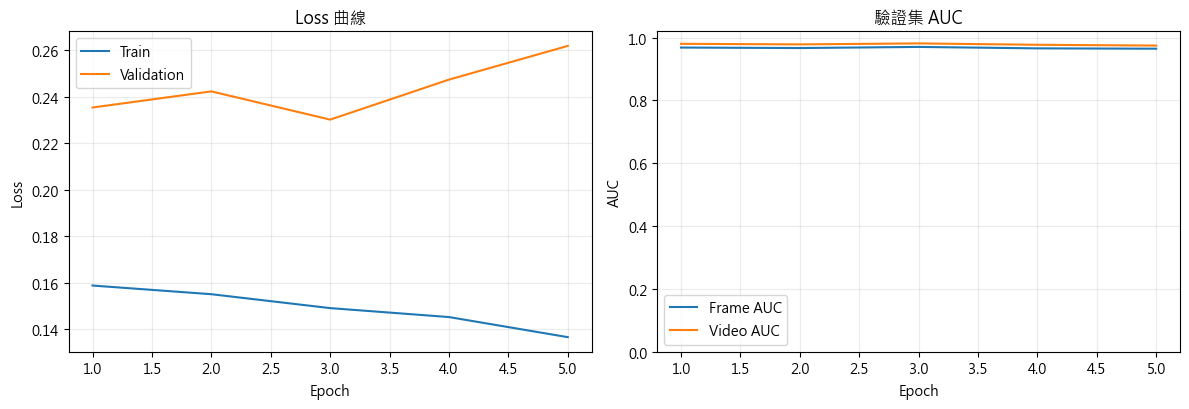

In [11]:
if HISTORY_PATH.is_file():
    history_df = pd.read_csv(HISTORY_PATH)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation")
    axes[0].set_title("Loss 曲線")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(
        history_df["epoch"],
        history_df["val_frame_auc"],
        label="Frame AUC",
    )
    axes[1].plot(
        history_df["epoch"],
        history_df["val_video_auc"],
        label="Video AUC",
    )
    axes[1].set_title("驗證集 AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("AUC")
    axes[1].set_ylim(0, 1.02)
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()
else:
    print("尚無 training_history.csv。")


## 11. 獨立測試集評估

**本節未執行。**

選模規則在實驗開始前就已固定為「依驗證集 video-level AUC 選取最佳權重」。Adapter 的最佳驗證 AUC（0.9816）始終未超過基準（0.9826），因此沒有理由動用測試集——若在明知未達基準的情況下仍去跑測試集，等於在期待測試集給出對自己有利的隨機波動。

測試集在本專案中只使用於已通過驗證集門檻的方法：03 與 07。

In [12]:
if not RUN_TEST:
    print("目前 RUN_TEST=False，尚未使用獨立測試集。")
elif SMOKE_TEST:
    raise ValueError("Smoke Test 不輸出正式測試結論。請先完成正式訓練。")
elif not BEST_MODEL_PATH.is_file():
    raise FileNotFoundError(f"找不到最佳模型：{BEST_MODEL_PATH}")
else:
    best_checkpoint = torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE,
        weights_only=False,
    )
    load_trainable_state(best_checkpoint["model_state_dict"])
    model.eval()

    with torch.no_grad():
        (
            test_loss,
            test_frame_metrics,
            test_video_metrics,
            test_frame_df,
            test_video_df,
        ) = run_epoch(model, dataloaders["test"], criterion)

    test_frame_df["prediction"] = (
        test_frame_df["fake_probability"] >= 0.5
    ).astype(int)
    test_video_df["prediction"] = (
        test_video_df["fake_probability"] >= 0.5
    ).astype(int)

    test_frame_df.to_csv(
        TEST_FRAME_PATH,
        index=False,
        encoding="utf-8-sig",
    )
    test_video_df.to_csv(
        TEST_VIDEO_PATH,
        index=False,
        encoding="utf-8-sig",
    )

    test_results = {
        "model_type": "CLIP residual feature adapter",
        "best_epoch": int(best_checkpoint["epoch"]) + 1,
        "loss": float(test_loss),
        "frame_level": test_frame_metrics,
        "video_level": test_video_metrics,
        "best_validation_video_auc": float(
            best_checkpoint["best_val_auc"]
        ),
    }
    with TEST_METRICS_PATH.open("w", encoding="utf-8") as file:
        json.dump(test_results, file, ensure_ascii=False, indent=2)

    print(json.dumps(test_results, ensure_ascii=False, indent=2))
    print("\nFrame-level Classification Report")
    print(
        classification_report(
            test_frame_df["label"],
            test_frame_df["prediction"],
            target_names=["Real", "Fake"],
            digits=4,
            zero_division=0,
        )
    )
    print("Video-level Classification Report")
    print(
        classification_report(
            test_video_df["label"],
            test_video_df["prediction"],
            target_names=["Real", "Fake"],
            digits=4,
            zero_division=0,
        )
    )


目前 RUN_TEST=False，尚未使用獨立測試集。


## 12. 混淆矩陣與 ROC Curve

因未執行測試，本節無輸出。

In [13]:
if "test_frame_df" not in globals():
    print("尚未執行正式測試。")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

    frame_cm = confusion_matrix(
        test_frame_df["label"],
        test_frame_df["prediction"],
        labels=[0, 1],
    )
    sns.heatmap(
        frame_cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Real", "Fake"],
        yticklabels=["Real", "Fake"],
        ax=axes[0],
    )
    axes[0].set_title("Frame-level 混淆矩陣")
    axes[0].set_xlabel("預測")
    axes[0].set_ylabel("實際")

    video_cm = confusion_matrix(
        test_video_df["label"],
        test_video_df["prediction"],
        labels=[0, 1],
    )
    sns.heatmap(
        video_cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Real", "Fake"],
        yticklabels=["Real", "Fake"],
        ax=axes[1],
    )
    axes[1].set_title("Video-level 混淆矩陣")
    axes[1].set_xlabel("預測")
    axes[1].set_ylabel("實際")

    plt.tight_layout()
    plt.show()

    fpr_frame, tpr_frame, _ = roc_curve(
        test_frame_df["label"],
        test_frame_df["fake_probability"],
    )
    fpr_video, tpr_video, _ = roc_curve(
        test_video_df["label"],
        test_video_df["fake_probability"],
    )

    plt.figure(figsize=(6, 5))
    plt.plot(
        fpr_frame,
        tpr_frame,
        label=f"Frame AUC={test_frame_metrics['auc']:.4f}",
    )
    plt.plot(
        fpr_video,
        tpr_video,
        label=f"Video AUC={test_video_metrics['auc']:.4f}",
    )
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("FF++ Test ROC Curve")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


尚未執行正式測試。


## 13. 錯誤分類案例

因未執行測試，本節無輸出。

In [14]:
if "test_frame_df" not in globals():
    print("尚未執行正式測試。")
else:
    errors_df = test_frame_df[
        test_frame_df["label"] != test_frame_df["prediction"]
    ].copy()
    errors_df["error_confidence"] = np.where(
        errors_df["prediction"].eq(1),
        errors_df["fake_probability"],
        1.0 - errors_df["fake_probability"],
    )
    errors_df = errors_df.sort_values(
        "error_confidence",
        ascending=False,
    )

    sample_count = min(12, len(errors_df))
    if sample_count == 0:
        print("測試集沒有錯誤分類圖片。")
    else:
        samples = errors_df.head(sample_count)
        columns = 4
        rows = math.ceil(sample_count / columns)
        fig, axes = plt.subplots(rows, columns, figsize=(12, 3 * rows))
        axes = np.array(axes).reshape(-1)

        for axis, (_, row) in zip(axes, samples.iterrows()):
            with Image.open(row["path"]) as image:
                axis.imshow(image.convert("RGB"))
            axis.set_title(
                f"實際={row['class_name']} / "
                f"P(Fake)={row['fake_probability']:.3f}"
            )
            axis.axis("off")

        for axis in axes[sample_count:]:
            axis.axis("off")

        plt.tight_layout()
        plt.show()


尚未執行正式測試。


## 實驗結論：負向結果

僅 133,762 個可訓練參數，在第 3 個 epoch 就開始過擬合，且最佳驗證 AUC 未超過完全凍結的線性基準。

**解釋**：在凍結 CLIP 的**最終輸出特徵**之後接瓶頸 Adapter，能學到的只是對既有 512 維語意特徵的重新加權。CLIP 的最後一層是為圖文語意對齊而訓練的，偽造痕跡所依賴的局部、高頻、空間性資訊在傳遞到這一層的過程中已大幅衰減。在資訊已經流失的地方增加參數量，只會讓模型更快記住訓練集。

這個負向結果直接支持了完整 Forensics Adapter 的設計動機：該方法從 CLIP 的第 1、8、15 層注入淺層特徵，並以 blending boundary 作為額外監督，正是為了取得最終特徵裡已經消失的那些資訊。07 驗證這條路線。